# **2802472426 - Kelly Natalia**

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_parquet('1A.parquet')

In [3]:
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status,yield
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,None,...,2024-01-08,2024-05-09,122,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild,44080.7
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,SENS0002,2024-04-21,16.613022,70.869009,0.58,None,53899.8
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild,29311.6
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,SENS0004,2024-05-14,31.071298,85.519998,0.44,None,42278.0
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,None,...,2024-02-05,2024-05-20,105,SENS0005,2024-04-13,16.56854,81.691720,0.84,Severe,49799.6


## **EDA**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    object 
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id            500 non-null    obj

In [5]:
# ada salah data type di soil_pH dan latitude
colsToConvert = ['soil_pH', 'latitude']

for col in colsToConvert:
    # ubah koma ke titik, lalu jadi angka
    df[col] = df[col].str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[['soil_pH', 'latitude']].dtypes)
df[['soil_pH', 'latitude']].head()

soil_pH     float64
latitude    float64
dtype: object


,soil_pH,latitude
0,5.99,14.970941
1,7.24,16.613022
2,7.16,19.503156
3,6.03,31.071298
4,5.92,16.568540


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   farm_id              500 non-null    object 
 1   region               500 non-null    object 
 2   crop_type            500 non-null    object 
 3   soil_moisture_%      500 non-null    float64
 4   soil_pH              500 non-null    float64
 5   temperature_C        500 non-null    float64
 6   rainfall_mm          500 non-null    float64
 7   humidity_%           500 non-null    float64
 8   sunlight_hours       499 non-null    float64
 9   irrigation_type      350 non-null    object 
 10  fertilizer_type      500 non-null    object 
 11  pesticide_usage_ml   500 non-null    float64
 12  sowing_date          500 non-null    object 
 13  harvest_date         500 non-null    object 
 14  total_days           500 non-null    int64  
 15  sensor_id            500 non-null    obj

In [7]:
df.shape

(500, 22)

In [8]:
df.columns

Index(['farm_id', 'region', 'crop_type', 'soil_moisture_%', 'soil_pH',
       'temperature_C', 'rainfall_mm', 'humidity_%', 'sunlight_hours',
       'irrigation_type', 'fertilizer_type', 'pesticide_usage_ml',
       'sowing_date', 'harvest_date', 'total_days', 'sensor_id', 'timestamp',
       'latitude', 'longitude', 'NDVI_index', 'crop_disease_status', 'yield'],
      dtype='object')

In [9]:
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,latitude,longitude,NDVI_index,yield
count,500.000000,500.000000,500.000000,500.000000,500.000000,499.000000,500.000000,500.000000,498.000000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.031904,26.586980,119.114000,22.464064,80.392248,0.602060,40329.269400
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.692908,13.202429,18.403107,7.285843,5.910664,0.175402,11744.330399
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.010000,5.050000,-50.000000,10.004243,70.020021,0.300000,20235.600000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.665000,14.945000,105.000000,16.274905,75.374713,0.447500,29948.200000
50%,25.855000,6.530000,24.655000,191.545000,65.685000,7.000000,25.980000,118.500000,22.032474,80.650284,0.610000,40716.900000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.470000,38.005000,134.000000,28.557783,85.654629,0.750000,50621.100000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.000000,49.940000,150.000000,34.981531,89.991901,0.900000,59982.900000


In [10]:
print(df.isnull().sum())

farm_id                  0
region                   0
crop_type                0
soil_moisture_%          0
soil_pH                  0
temperature_C            0
rainfall_mm              0
humidity_%               0
sunlight_hours           1
irrigation_type        150
fertilizer_type          0
pesticide_usage_ml       0
sowing_date              0
harvest_date             0
total_days               0
sensor_id                0
timestamp                0
latitude                 2
longitude                0
NDVI_index               0
crop_disease_status    130
yield                    0
dtype: int64


In [11]:
modeIrrigation = df['irrigation_type'].mode()[0]
modeDisease = df['crop_disease_status'].mode()[0]

print(f"modus untuk irrigation_type: {modeIrrigation}")
print(f"modus untuk crop_disease_status: {modeDisease}")

print("\nfrekuensi irrigation_type:")
print(df['irrigation_type'].value_counts())

print("\nfrekuensi crop_disease_status:")
print(df['crop_disease_status'].value_counts())

modus untuk irrigation_type: Sprinkler
modus untuk crop_disease_status: Severe

frekuensi irrigation_type:
irrigation_type
Sprinkler    121
Manual       118
Drip         111
Name: count, dtype: int64

frekuensi crop_disease_status:
crop_disease_status
Severe      133
Mild        125
Moderate    112
Name: count, dtype: int64


In [12]:
df['irrigation_type'] = df['irrigation_type'].fillna(modeIrrigation)
df['crop_disease_status'] = df['crop_disease_status'].fillna(modeDisease)

<Axes: xlabel='sunlight_hours', ylabel='Count'>

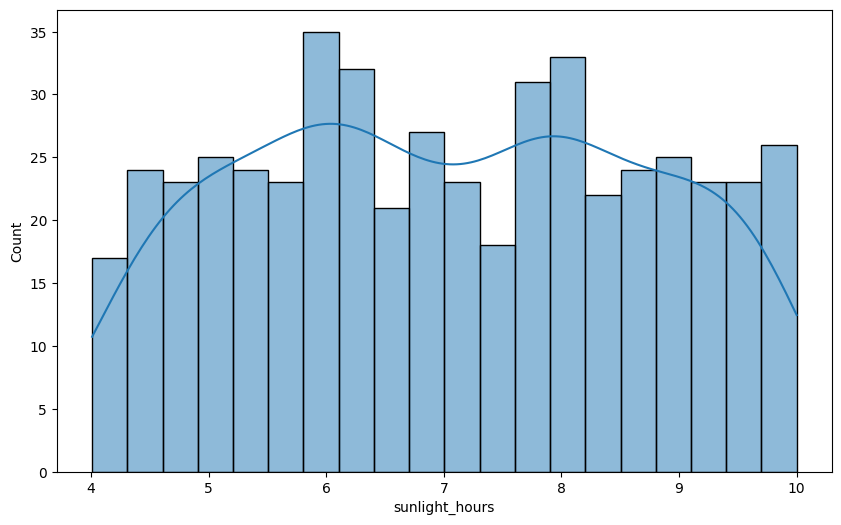

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df["sunlight_hours"].dropna(), bins=20, kde=True)

<Axes: xlabel='latitude', ylabel='Count'>

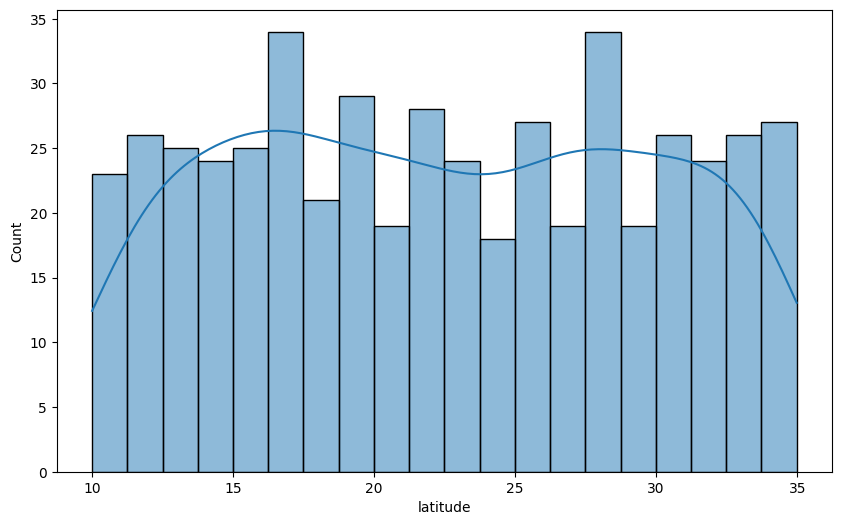

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df["latitude"].dropna(), bins=20, kde=True)

datanya agak skewed, terutama yang latitude, dia punya dua puncak (bimodal) dan distribusinya nggak berbentuk lonceng simetris sama sekali. maka dari itu untuk isi na akan digunakan median

In [15]:
df['sunlight_hours'] = df['sunlight_hours'].fillna(df['sunlight_hours'].median())
df['latitude'] = df['latitude'].fillna(df['latitude'].median())

In [16]:
print(df.isnull().sum())

farm_id                0
region                 0
crop_type              0
soil_moisture_%        0
soil_pH                0
temperature_C          0
rainfall_mm            0
humidity_%             0
sunlight_hours         0
irrigation_type        0
fertilizer_type        0
pesticide_usage_ml     0
sowing_date            0
harvest_date           0
total_days             0
sensor_id              0
timestamp              0
latitude               0
longitude              0
NDVI_index             0
crop_disease_status    0
yield                  0
dtype: int64


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
cat = ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']

for col in cat:
    print(f"Unique values in {col}:")
    print(df[col].unique())

Unique values in region:
['North India' 'South USA' 'Central USA' 'East Africa' 'South India']
Unique values in crop_type:
['Wheat' 'Soybean' 'Maize' 'Cotton' 'Rice']
Unique values in irrigation_type:
['Sprinkler' 'Drip' 'Manual']
Unique values in fertilizer_type:
['Organic' 'Inorganic' 'Mixed']
Unique values in crop_disease_status:
['Mild' 'Severe' 'Moderate']


In [19]:
num = df.select_dtypes(exclude = 'object').columns

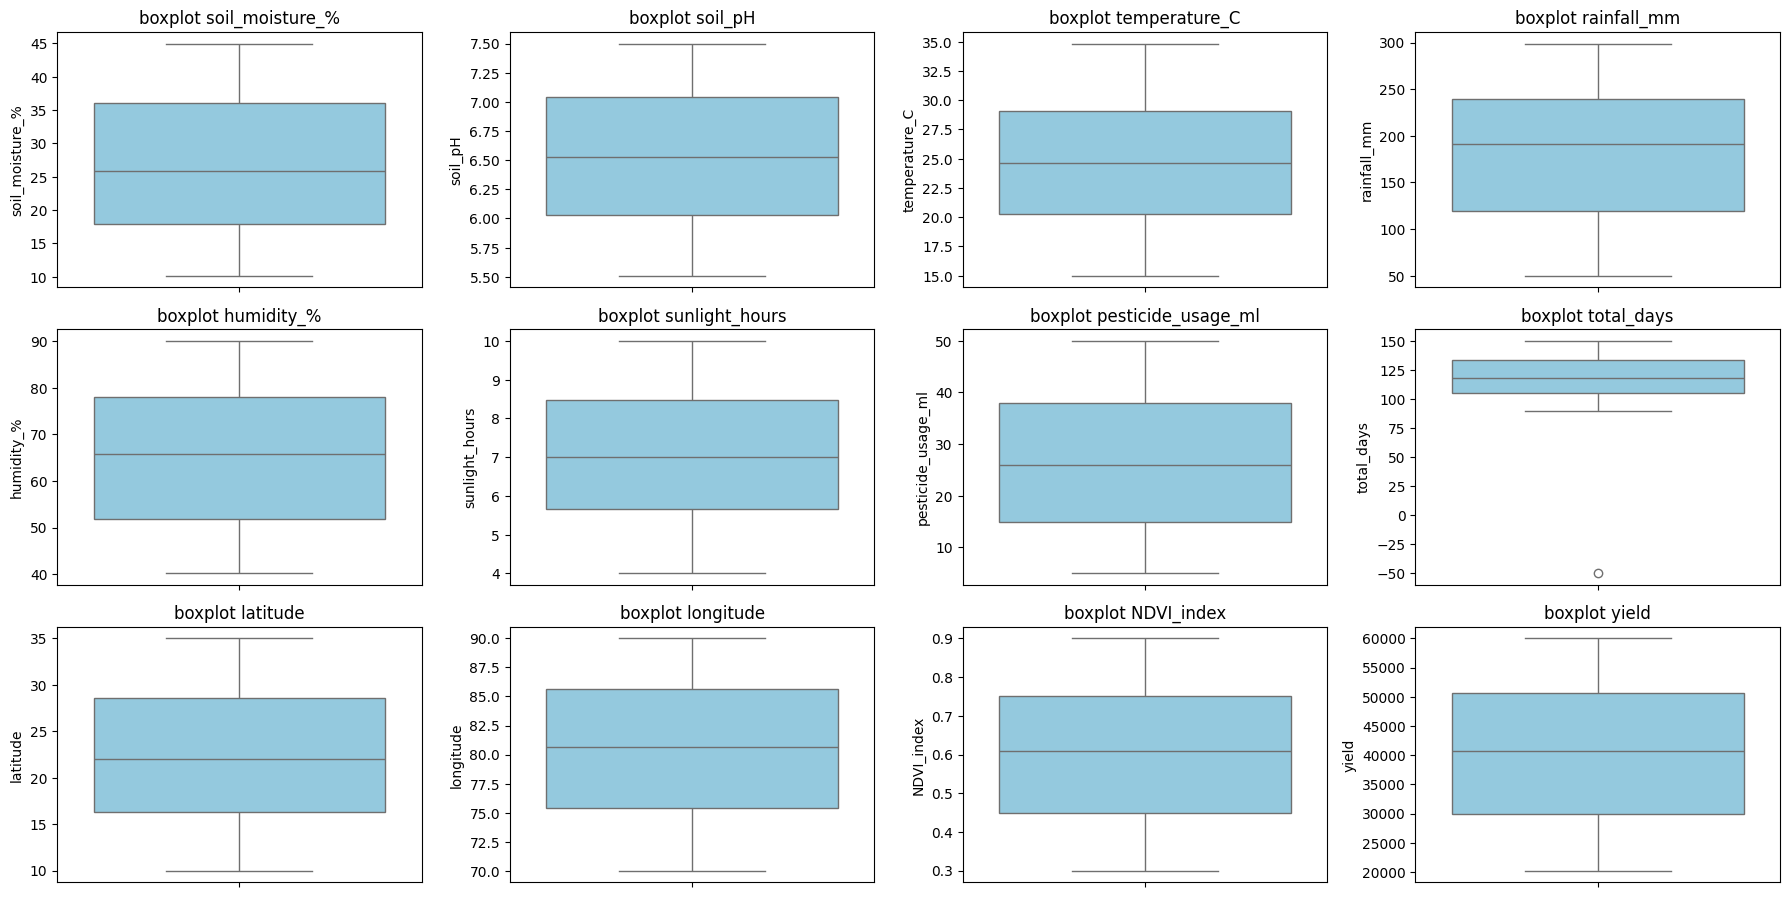

In [20]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(num):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'boxplot {col}')

plt.tight_layout()
plt.show()

In [21]:
outliers_info = {}
audit_results = {}

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_info[col] = {'count': count, 'lower': lower, 'upper': upper}
audit_results['outliers'] = outliers_info


for col, info in audit_results['outliers'].items():
    print(f"Outlier in {col}: {info['count']} (Range: {info['lower']:.2f} to {info['upper']:.2f})")

Outlier in soil_moisture_%: 0 (Range: -9.31 to 63.22)
Outlier in soil_pH: 0 (Range: 4.52 to 8.55)
Outlier in temperature_C: 0 (Range: 7.10 to 42.28)
Outlier in rainfall_mm: 0 (Range: -60.51 to 418.76)
Outlier in humidity_%: 0 (Range: 12.67 to 117.19)
Outlier in sunlight_hours: 0 (Range: 1.46 to 12.67)
Outlier in pesticide_usage_ml: 0 (Range: -19.65 to 72.59)
Outlier in total_days: 1 (Range: 61.50 to 177.50)
Outlier in latitude: 0 (Range: -2.07 to 46.89)
Outlier in longitude: 0 (Range: 59.95 to 101.07)
Outlier in NDVI_index: 0 (Range: -0.01 to 1.20)
Outlier in yield: 0 (Range: -1061.15 to 81630.45)


In [25]:
# hapus baris total_days yang minus
df = df[df['total_days'] >= 0]
print("Nilai minimum total_days:", df['total_days'].min())

Nilai minimum total_days: 90


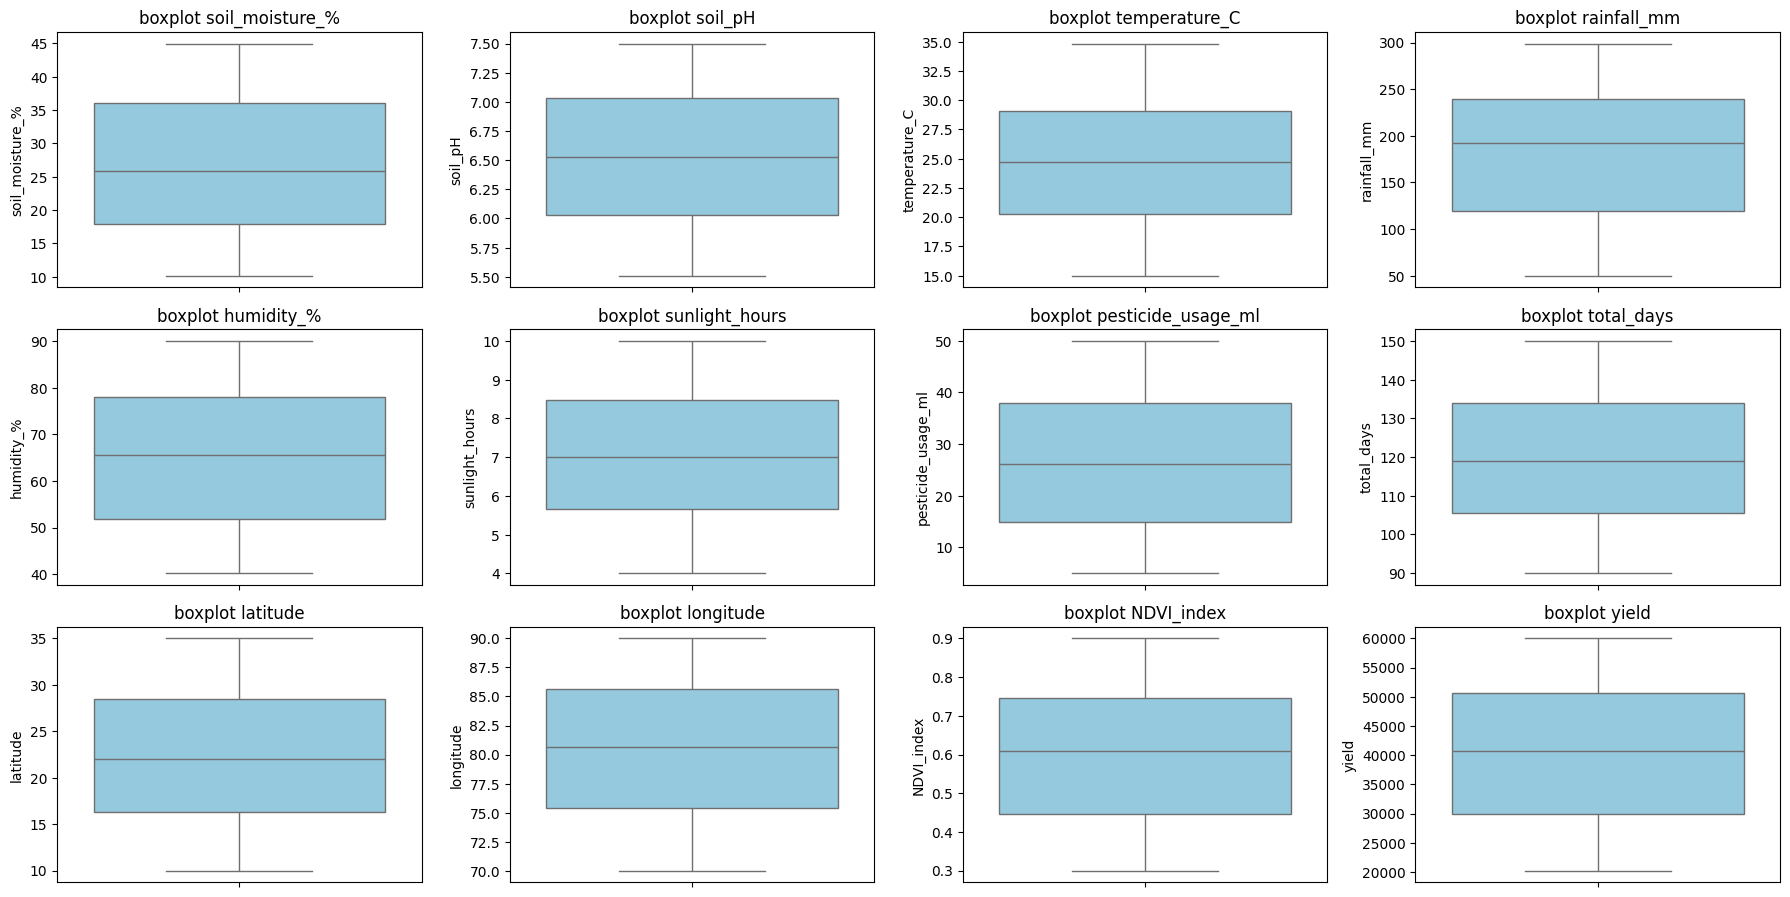

In [26]:
plt.figure(figsize=(18, 12))
for i, col in enumerate(num):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'boxplot {col}')

plt.tight_layout()
plt.show()

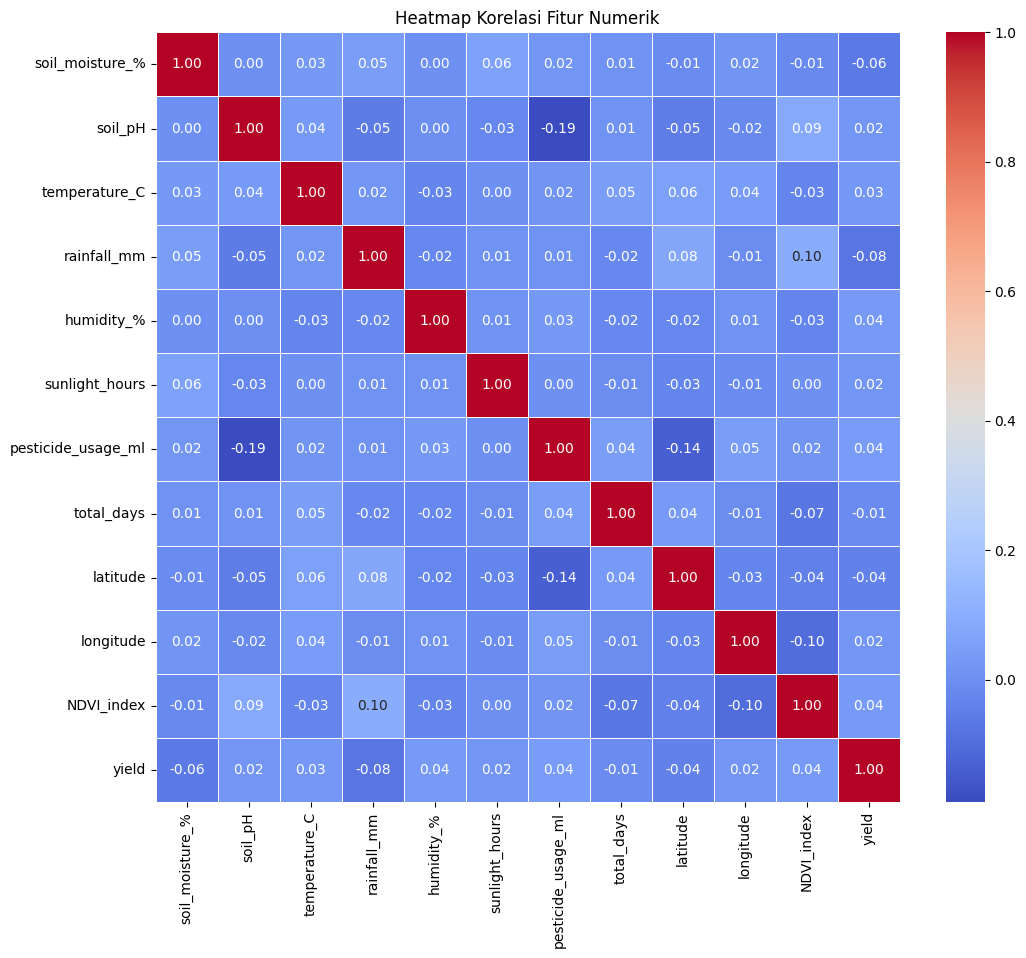

korelasi fitur terhadap yield:
yield                 1.000000
pesticide_usage_ml    0.042887
humidity_%            0.038153
NDVI_index            0.036819
temperature_C         0.029167
longitude             0.022721
soil_pH               0.022675
sunlight_hours        0.020954
total_days           -0.008919
latitude             -0.037644
soil_moisture_%      -0.062488
rainfall_mm          -0.075344
Name: yield, dtype: float64


In [27]:
plt.figure(figsize=(12, 10))
numericOnly = df.select_dtypes(include=[np.number])
corrMatrix = numericOnly.corr()

# plot heatmap
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.show()

print("korelasi fitur terhadap yield:")
print(corrMatrix['yield'].sort_values(ascending=False))

In [28]:
dropCols = ['farm_id', 'sensor_id', 'sowing_date', 'harvest_date', 'timestamp']
dfClean = df.drop(columns=dropCols)

udah ada total_days itu yang hasil pengurangan harvest_date minus sowing_date jadi gausa ada lagi kolom harvest_date & sowing_date

In [29]:
dfClean.head()

,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,total_days,latitude,longitude,NDVI_index,crop_disease_status,yield
0,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,Sprinkler,Organic,6.34,122,14.970941,82.997689,0.63,Mild,44080.7
1,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,Inorganic,9.60,112,16.613022,70.869009,0.58,Severe,53899.8
2,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,Mixed,15.26,144,19.503156,79.068206,0.80,Mild,29311.6
3,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,Organic,25.80,134,31.071298,85.519998,0.44,Severe,42278.0
4,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,Sprinkler,Mixed,25.65,105,16.568540,81.691720,0.84,Severe,49799.6


## **Modeling**

In [91]:
x = dfClean.drop(columns=['yield'])
y = dfClean['yield']

In [92]:
# split data dengan proporsi 70:10:20
xTrain, xTemp, yTrain, yTemp = train_test_split(x, y, test_size=0.3, random_state=42)
xVal, xTest, yVal, yTest = train_test_split(xTemp, yTemp, test_size=0.6666, random_state=42)

In [93]:
numCols = ['soil_moisture_%', 'soil_pH', 'temperature_C', 'rainfall_mm',
           'humidity_%', 'sunlight_hours', 'pesticide_usage_ml',
           'total_days', 'latitude', 'longitude', 'NDVI_index']
catCols = ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']

In [94]:
numPipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [95]:
preprocessor = ColumnTransformer([
    ('num', numPipeline, numCols),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), catCols)
])

In [96]:
xTrainScaled = preprocessor.fit_transform(xTrain)
xValScaled = preprocessor.transform(xVal)
xTestScaled = preprocessor.transform(xTest)

In [97]:
print(f"Training set: {len(xTrainScaled)} samples")
print(f"Validation set: {len(xValScaled)} samples")
print(f"Testing set: {len(xTestScaled)} samples")

Training set: 349 samples
Validation set: 50 samples
Testing set: 100 samples


In [98]:
inputDimension = xTrainScaled.shape[1]
minNeurons = inputDimension * 2

In [99]:
# baseline model
modelBaseline = keras.Sequential([
    # layer 1
    keras.layers.Dense(minNeurons, activation='relu', input_shape=(inputDimension,)),
    # layer 2
    keras.layers.Dense(minNeurons, activation='relu'),
    # output
    keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [100]:
# compile model
modelBaseline.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', tf.keras.metrics.R2Score(name='r2_score')]
)

In [105]:
historyBaseline = modelBaseline.fit(
    xTrainScaled, yTrain,
    validation_data=(xValScaled, yVal),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 130480416.0000 - mae: 9976.6924 - r2_score: 0.0421 - val_loss: 141074192.0000 - val_mae: 10237.7393 - val_r2_score: -0.1332
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 130404408.0000 - mae: 9972.8076 - r2_score: 0.0426 - val_loss: 141050752.0000 - val_mae: 10239.5820 - val_r2_score: -0.1330
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 130354624.0000 - mae: 9969.4561 - r2_score: 0.0430 - val_loss: 141178096.0000 - val_mae: 10247.8652 - val_r2_score: -0.1340
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 130299112.0000 - mae: 9967.1816 - r2_score: 0.0434 - val_loss: 141108032.0000 - val_mae: 10248.8252 - val_r2_score: -0.1335
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 130276152.0000 - mae: 9964.9697 - r2_score: 0.0436 - val_loss: 141085760.0000 - val_mae: 10250.0771 - val_r2_score: -0.1333
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 130236488.0000 - mae:

In [106]:
# prediksi hasil panen menggunakan data testing
yPred = modelBaseline.predict(xTestScaled).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


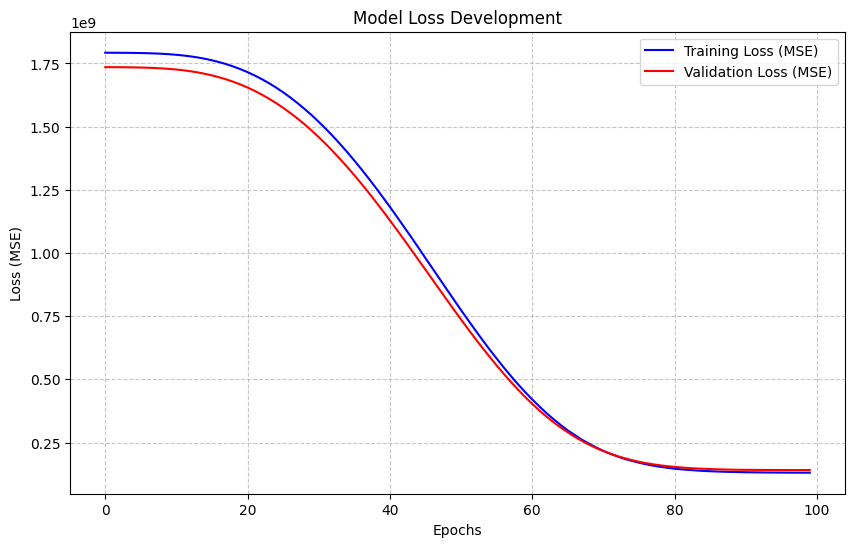

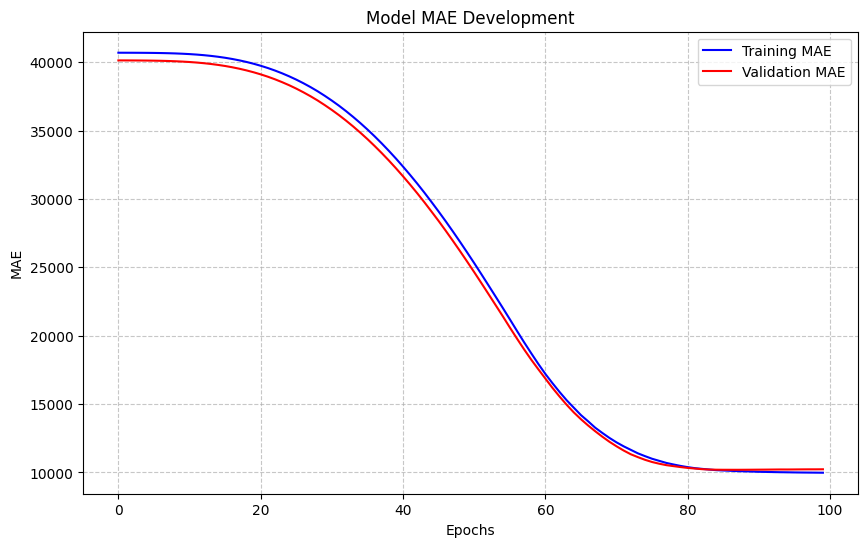

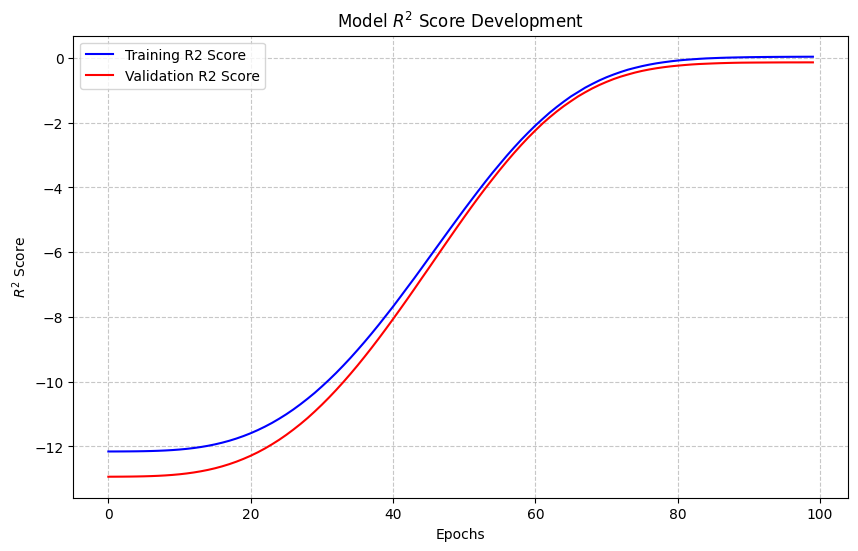

In [103]:
# mse
plt.figure(figsize=(10, 6))
plt.plot(historyBaseline.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(historyBaseline.history['val_loss'], label='Validation Loss (MSE)', color='red')
plt.title('Model Loss Development')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# mae
plt.figure(figsize=(10, 6))
plt.plot(historyBaseline.history['mae'], label='Training MAE', color='blue')
plt.plot(historyBaseline.history['val_mae'], label='Validation MAE', color='red')
plt.title('Model MAE Development')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# r2 score
plt.figure(figsize=(10, 6))
plt.plot(historyBaseline.history['r2_score'], label='Training R2 Score', color='blue')
plt.plot(historyBaseline.history['val_r2_score'], label='Validation R2 Score', color='red')
plt.title('Model $R^2$ Score Development')
plt.xlabel('Epochs')
plt.ylabel('$R^2$ Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [107]:
print("R2 Score :", r2_score(yTest, yPred))
print("MSE      :", mean_squared_error(yTest, yPred))
print("MAE      :", mean_absolute_error(yTest, yPred))
print("MAPE     :", mean_absolute_percentage_error(yTest, yPred))

R2 Score : -0.0589274377041753
MSE      : 156973850.1622808
MAE      : 10892.048671874998
MAPE     : 0.3317484115143516


## **Modify Model**

In [139]:
targetScaler = StandardScaler()
yTrainScaled = targetScaler.fit_transform(yTrain.values.reshape(-1, 1)).flatten()
yValScaled = targetScaler.transform(yVal.values.reshape(-1, 1)).flatten()

In [151]:
def buildModifiedModel(inputShape):
    model = keras.Sequential([
        keras.layers.Input(shape=(inputShape,)),
        keras.layers.Dense(128),
        keras.layers.LeakyReLU(alpha=0.1),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64),
        keras.layers.LeakyReLU(alpha=0.1),
        keras.layers.Dense(32),
        keras.layers.LeakyReLU(alpha=0.1),
        keras.layers.Dense(1)
    ])

    optimizer = keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='huber')
    return model

inputDimension = xTrainScaled.shape[1]
modifiedModel = buildModifiedModel(inputDimension)

earlyStop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_bestyPredModScaled = modifiedModel.predict(xTestScaled)
yPredModFinal = targetScaler.inverse_transform(yPredModScaled).flatten()

print("R2 Score :", r2_score(yTest, yPredModFinal))
print("MSE      :", mean_squared_error(yTest, yPredModFinal))
print("MAE      :", mean_absolute_error(yTest, yPredModFinal))
print("MAPE     :", mean_absolute_percentage_error(yTest, yPredModFinal))_weights=True
)

historyModified = modifiedModel.fit(
    xTrainScaled, yTrainScaled,
    validation_data=(xValScaled, yValScaled),
    epochs=200,
    batch_size=16,
    callbacks=[earlyStop],
    verbose=1
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.5679 - val_loss: 0.4745
Epoch 2/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4523 - val_loss: 0.4739
Epoch 3/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3984 - val_loss: 0.4708
Epoch 4/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3507 - val_loss: 0.4797
Epoch 5/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3154 - val_loss: 0.4830
Epoch 6/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2817 - val_loss: 0.4814
Epoch 7/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2642 - val_loss: 0.4900
Epoch 8/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2393 - val_loss: 0.4966
Epoch 9/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2153 - val_loss: 0.4798
Epoch 10/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1897 - val_loss: 0.4746
Epoch 11/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1793 - val_loss: 0.4868
Epoch 12/200
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1642 - val_l

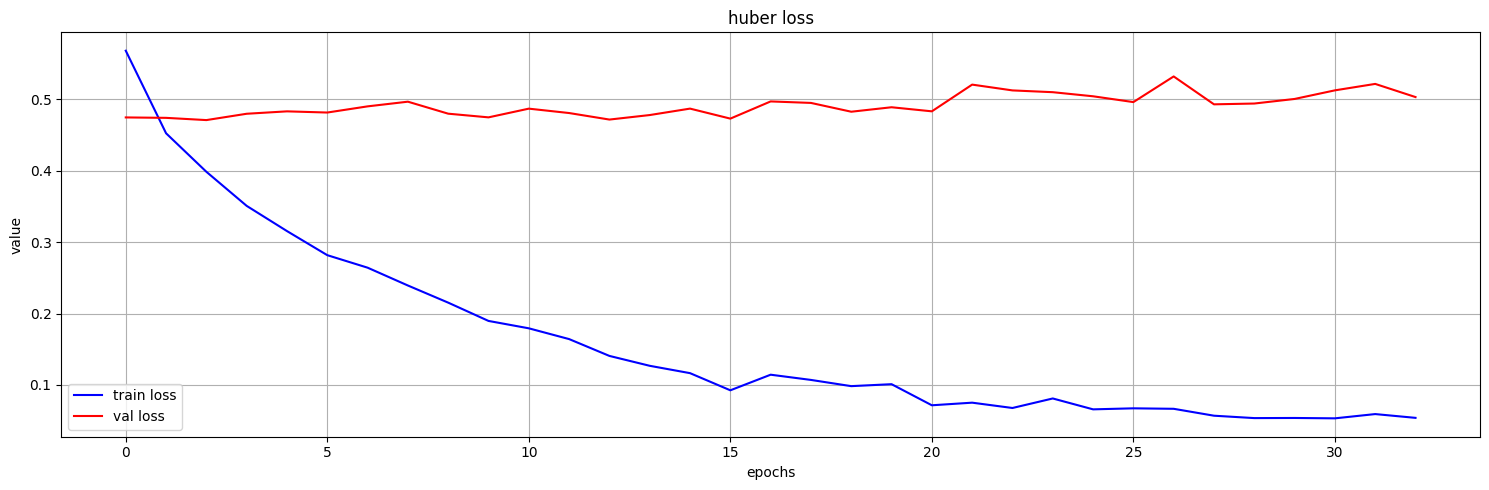

In [155]:
metricsToPlot = ['loss', 'mae', 'r2_score']
titles = ['huber loss', 'mean absolute error', 'r2 score']

validMetrics = []
validTitles = []
for i, m in enumerate(metricsToPlot):
    if m in historyModified.history:
        validMetrics.append(m)
        validTitles.append(titles[i])

plt.figure(figsize=(15, 5))
for i, metric in enumerate(validMetrics):
    plt.subplot(1, len(validMetrics), i+1)

    plt.plot(historyModified.history[metric], label=f'train {metric}', color='blue')
    plt.plot(historyModified.history[f'val_{metric}'], label=f'val {metric}', color='red')

    plt.title(validTitles[i])
    plt.xlabel('epochs')
    plt.ylabel('value')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [157]:
yPredModScaled = modifiedModel.predict(xTestScaled)
yPredModFinal = targetScaler.inverse_transform(yPredModScaled).flatten()

print("R2 Score :", r2_score(yTest, yPredModFinal))
print("MSE      :", mean_squared_error(yTest, yPredModFinal))
print("MAE      :", mean_absolute_error(yTest, yPredModFinal))
print("MAPE     :", mean_absolute_percentage_error(yTest, yPredModFinal))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
R2 Score : 0.02386306593512777
MSE      : 136834177.84169772
MAE      : 10222.237796875
MAPE     : 0.29431156860742447


## **Perbandingan**

In [152]:
yPredModScaled = modifiedModel.predict(xTestScaled)
yPredModFinal = targetScaler.inverse_transform(yPredModScaled).flatten()

finalR2 = r2_score(yTest, yPredModFinal)
finalMae = mean_absolute_error(yTest, yPredModFinal)

performanceMetrics = [
    {
        'Model': 'Baseline Model',
        'MAE': mean_absolute_error(yTest, yPred),
        'R2': r2_score(yTest, yPred)
    },
    {
        'Model': 'Modified Model',
        'MAE': finalMae,
        'R2': finalR2
    }
]

dfPerformance = pd.DataFrame(performanceMetrics)
display(dfPerformance)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


,Model,MAE,R2
0,Baseline Model,10617.458945,-0.050611
1,Modified Model,10222.237797,0.023863


### Penjelasan Modifikasi & Hasil Evaluasi

Model Baseline sebelumnya menghasilkan nilai $R^2$ negatif karena rentang data target (yield) yang sangat besar dan fluktuatif. Pada Modified Model, diterapkan beberapa optimasi kunci untuk mengatasi masalah tersebut:

1. Target Scaling (StandardScaler): Menormalkan skala target yield sebelum proses training agar model lebih stabil belajar dan terhindar dari gradient explosion.
2. Huber Loss: Mengganti metrik loss MSE dengan Huber Loss yang lebih kebal (robust) terhadap keberadaan pencilan data (outliers).
3. Arsitektur Model: Menggunakan LeakyReLU untuk mencegah dead neurons dan menambahkan BatchNormalization agar aliran data antar layer tetap seimbang.

**Kesimpulan:**

Modifikasi ini terbukti efektif. Nilai $R^2$ Score berhasil naik dari negatif menjadi positif (0.023), menandakan model kini mampu menangkap pola data lebih baik daripada sekadar menebak nilai rata-rata. Selain itu, tingkat akurasi juga meningkat yang ditunjukkan dengan penurunan nilai MAE dari 10.617 menjadi 10.222.